In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import glob
from time import time

from RaTag.core.datatypes import Run, SetPmt
from RaTag.core.config import  AlphaCalibrationConfig

from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.io import file_ops
from RaTag.alphas.alphas_workflow import map_alpha_events, resolve_alpha_energies
from RaTag.alphas.alphas_calibration import map_alpha_calibrations, map_alpha_plots

# Initialize test run and set

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'  # Multi-isotope run with 3 alpha sets!

run = bootstrap_from_config(config_path)

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [4]:
config = file_ops.load_yaml(config_path, )
alpha_config_dict = config.get('energy_mapping', None)
alpha_config = AlphaCalibrationConfig(**alpha_config_dict) if alpha_config_dict else None
alpha_config

AlphaCalibrationConfig(max_frames=None, n_pedestal=10000, window_ma=1000, threshold_bs=0.7, savgol_window=501, pattern='*.wfm', nbins=200, n_sigma={'Th228': [6.0, 2.0], 'Ra224': [2.0, 3.0], 'Bi212': [1.0, 1.0], 'Rn220': [2.0, 2.0], 'default': [3.0, 3.0]}, use_quadratic=True, energy_range=[4, 10.2])

# Compute Alpha Energies

In [5]:
aset0 = run.alpha_sets[0]

In [8]:
setOG = resolve_alpha_energies(aset0, max_frames = 10_000,
                               config=alpha_config, force=True)

  🔹 Resolving alpha energies for: FieldScan_Gate0120_Anode1120
  Iterating FieldScan_Gate0120_Anode1120: 11/11 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_alpha_energies' and stored metadata


In [7]:
rset0 = resolve_alpha_energies(aset0, max_frames = 10_000,
                               config=alpha_config, force=True)

  🔹 Resolving alpha energies for: FieldScan_Gate0120_Anode1120
  Iterating FieldScan_Gate0120_Anode1120: 11/11 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_alpha_energies' and stored metadata


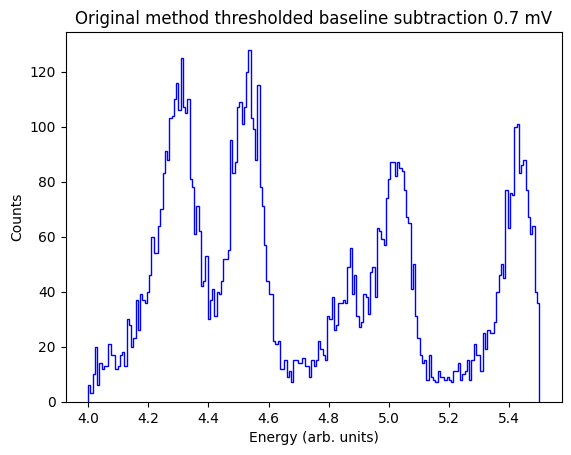

In [10]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(4, 5.5),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
            title='Original method thresholded baseline subtraction 0.7 mV');

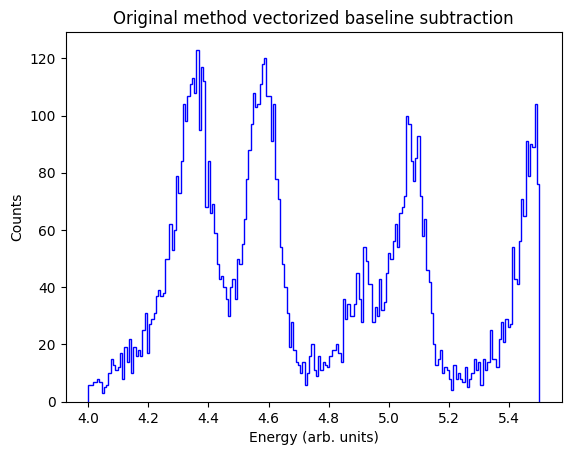

In [11]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies_OG+vectorized_baseline_subtraction/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(4, 5.5),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
             title='Original method vectorized baseline subtraction');

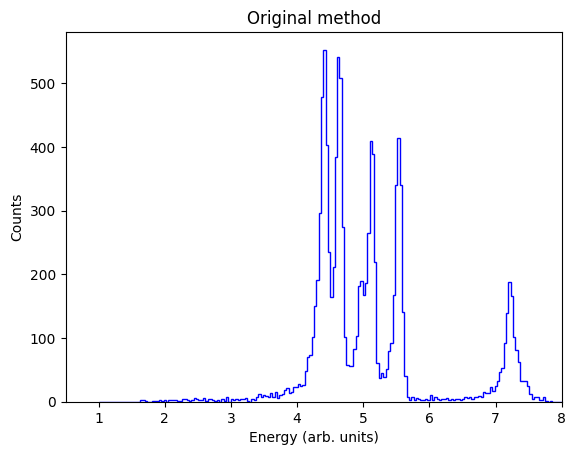

In [ ]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies_OG/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(1, 8),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
              xlim=(0.5, 8), title='Original method');

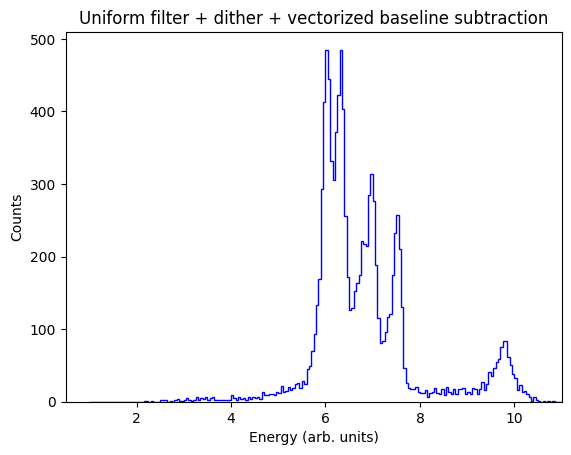

In [11]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(1, 11),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
              xlim=(0.5, 11), title='Uniform filter + dither + vectorized baseline subtraction');

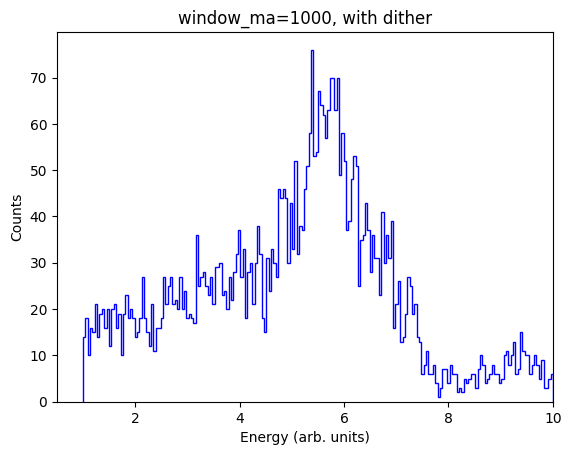

In [ ]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies_uniform/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(1, 10),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
              xlim=(0.5, 10), title='window_ma=1000, with dither');

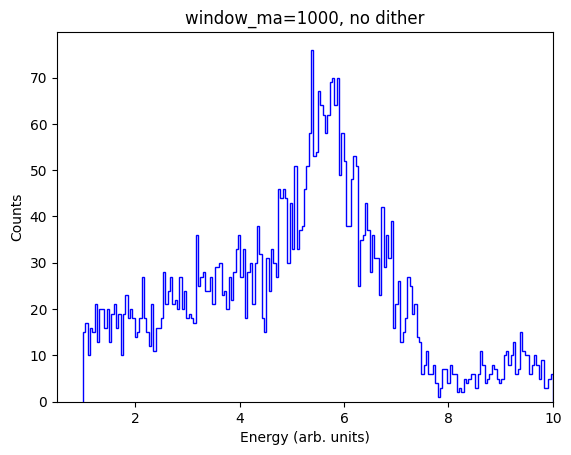

In [ ]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(1, 10),
         histtype='step', color='blue', label='Alpha Energies');
plt.gca().set(xlabel='Energy (arb. units)', ylabel='Counts', 
              xlim=(0.5, 10), title='window_ma=1000, no dither');

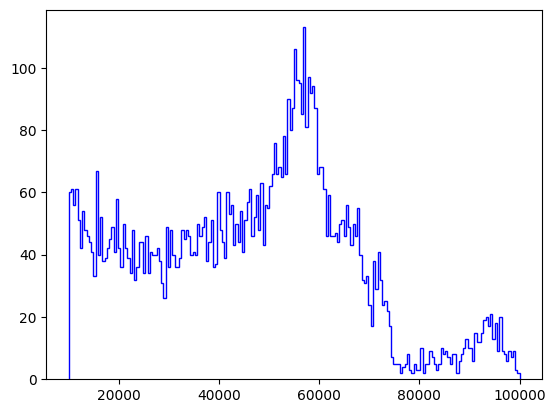

In [ ]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range =(10_000, 100_000),
         histtype='step', color='blue', label='Alpha Energies');

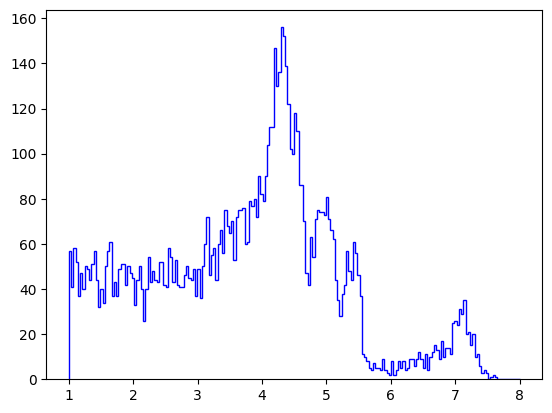

In [ ]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range=(1, 8), histtype='step', color='blue', label='Alpha Energies');

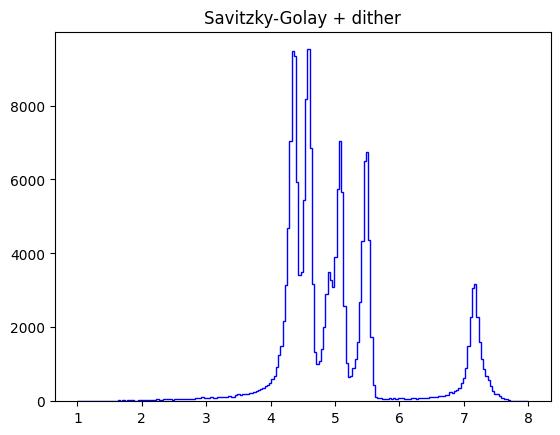

In [92]:
alphapath = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies_SG/FieldScan_Gate0120_Anode1120_alpha_energies.npz'
energies = np.load(alphapath, allow_pickle=True)['energies']
plt.hist(energies, bins=200, range=(1, 8), histtype='step', color='blue');
plt.title('Savitzky-Golay + dither');

In [8]:
runa = map_alpha_events(run, force=True)


RECONSTRUCTING ALPHA ENERGIES: RUN_36
  🔹 Resolving alpha energies for: FieldScan_Gate0120_Anode1120
  Iterating FieldScan_Gate0120_Anode1120: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0156_Anode1156
  Iterating FieldScan_Gate0156_Anode1156: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0156_Anode1156: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0188_Anode1188
  Iterating FieldScan_Gate0188_Anode1188: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0188_Anode1188: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0216_Anode1216
  Iterating FieldScan_Gate0216_Anode1216: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0216_Anode1216: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0288_Anode1288
  Iterating FieldScan_Gate

# Check waveforms

In [24]:
from RaTag.core.dataIO import load_alpha
from RaTag.plotting import plot_waveform
from RaTag.waveform.preprocessing import *
from scipy.signal import savgol_filter

In [25]:
wf = load_alpha(aset0.source_dir / aset0.filenames[0])
wf_sub = subtract_thresholded_pedestal(wf)
wf_smooth = moving_average(wf, window=1000)
wf_clip = threshold_clip(wf_smooth, threshold=0.025)
v = wf_sub.v[0, :]
wf_sg = savgol_filter(v, window_length=501, polyorder=3)

In [42]:
thresholds = [0.05, 0.1, 0.3, 0.7]
pedestals = {}
for threshold_bs in thresholds:
    masked_slice = np.where(wf.v < threshold_bs, wf.v, np.nan)

    # 3. Count valid points to replicate the `len(v_bs) >= 10` condition
    valid_counts = np.sum(~np.isnan(masked_slice), axis=1, keepdims=True)

    pedestals[threshold_bs] = np.nanmean(masked_slice, axis=1, keepdims=True)

In [38]:
mins = np.min(wf_smooth.v, axis=1)

In [18]:
len(baselines), len(pedestals)

(987, 987)

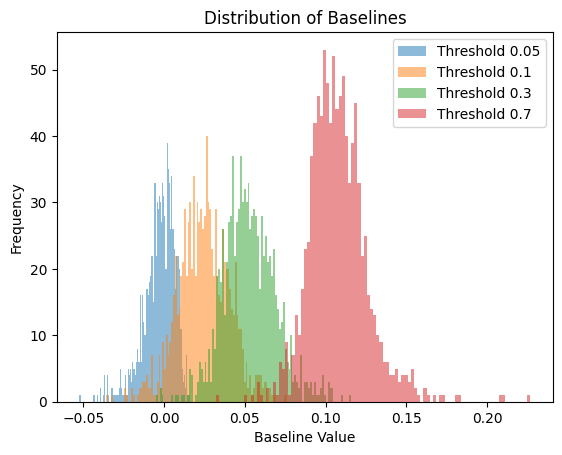

In [43]:
for k, v in pedestals.items():
    plt.hist(v, bins=100, alpha=0.5, label=f'Threshold {k}');
# plt.hist(mins, bins=100, alpha=0.5, label='Minimum value');
plt.xlabel('Baseline Value');
plt.ylabel('Frequency');
plt.title('Distribution of Baselines');
plt.legend();
plt.show();

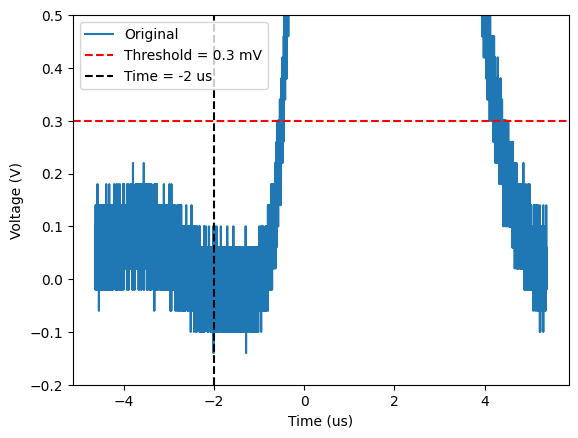

In [34]:
frame_idx += 1

plt.plot(wf.t, wf.v[frame_idx, :], label='Original')
# plt.plot(wf_sub.t, wf_sub.v[frame_idx, :], label='Pedestal Subtracted')
# plt.plot(wf_smooth.t, wf_smooth.v[frame_idx, :], color='lime', label='Smoothed window=100')
# plt.plot(wf_clip.t, wf_clip.v[frame_idx, :], label='Threshold Clipped')
# plt.plot(wf_sub.t, wf_sg, color='red', label='Savitzky-Golay window=501, polyorder=3')
plt.gca().set(xlabel='Time (us)', ylabel='Voltage (V)', ylim=(-0.2, 0.5))
plt.axhline(y=0.3, color='r', linestyle='--', label='Threshold = 0.3 mV')
plt.axvline(x=-2, color='k', linestyle='--', label='Time = -2 us')
plt.legend()

In [26]:
len(wf.t[wf.t < -2])

13151

# Perform alpha fit and calibration

In [6]:
runc = map_alpha_calibrations(runa, force=False)
_ = map_alpha_plots(runc, force=True)


CALIBRATING ALPHA ENERGIES: RUN_35
  Calibrating alpha spectrum for FieldScan_Gate0120_Anode0920...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0120_Anode0920_alpha_energies.npz
    ✓ Bayesian overlap resolved at 4.475 mV
    ✓ Calibration successful. Mean Resolution: 2.99%
  ✓ FieldScan_Gate0120_Anode0920: Computed 'calib_a' and stored metadata
  Calibrating alpha spectrum for FieldScan_Gate0156_Anode0956...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0156_Anode0956_alpha_energies.npz
    ✓ Bayesian overlap resolved at 4.441 mV
    ✓ Calibration successful. Mean Resolution: 2.70%
  ✓ FieldScan_Gate0156_Anode0956: Computed 'calib_a' and stored metadata
  Calibrating alpha spectrum for FieldScan_Gate0188_Anode0988...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Ga

# Debug single set

In [11]:
from RaTag.io import file_ops
from RaTag.alphas.alphas_plotting import plot_calibration_summary
from RaTag.alphas.alphas_calibration import _load_alpha_fits
from RaTag.core.config import ALPHA_PEAK_DEFINITIONS

In [5]:
set_alpha = runa.alpha_sets[0]
set_alpha

SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0120_Anode0720
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  ff = True
  nframes = 944
  gate = 120
  anode = 720
  n_alpha_energies = 49350
  calib_a = -0.08
  calib_b = 2.129
  calib_c = -2.321
  calib_order = 2
  mean_energy_resolution = 0.027
  isotope_ranges_V = {'Th228': [4.284, 4.391], 'Ra224': [4.511, 4.617], 'Bi212': [4.83, 4.979], 'Rn220': [5.027, 5.117], 'Po216': [5.414, 5.503], 'Po212': [7.062, 7.217]}
  isotope_ranges_E = {'Th228': [5.325, 5.478], 'Ra224': [5.647, 5.796], 'Bi212': [6.088, 6.288], 'Rn220': [6.351, 6.47], 'Po216': [6.851, 6.962], 'Po212': [8.709, 8.862]}

  Missing:
    sampling_rate

In [14]:
arrays = file_ops.load_npz_arrays(set_alpha, 'alpha_energies')
energies_SCA = arrays['energies']

fit_results = _load_alpha_fits(set_alpha)
fit_results

{'Th228': <lmfit.model.ModelResult at 0x1305f6220>,
 'Ra224': <lmfit.model.ModelResult at 0x13032db50>,
 'Bi212': <lmfit.model.ModelResult at 0x130622e50>,
 'Rn220': <lmfit.model.ModelResult at 0x130434fa0>,
 'Po216': <lmfit.model.ModelResult at 0x1304578b0>,
 'Po212': <lmfit.model.ModelResult at 0x130434e80>}

In [18]:
set_alpha.isotope_ranges_V['Th228']

[4.284, 4.391]

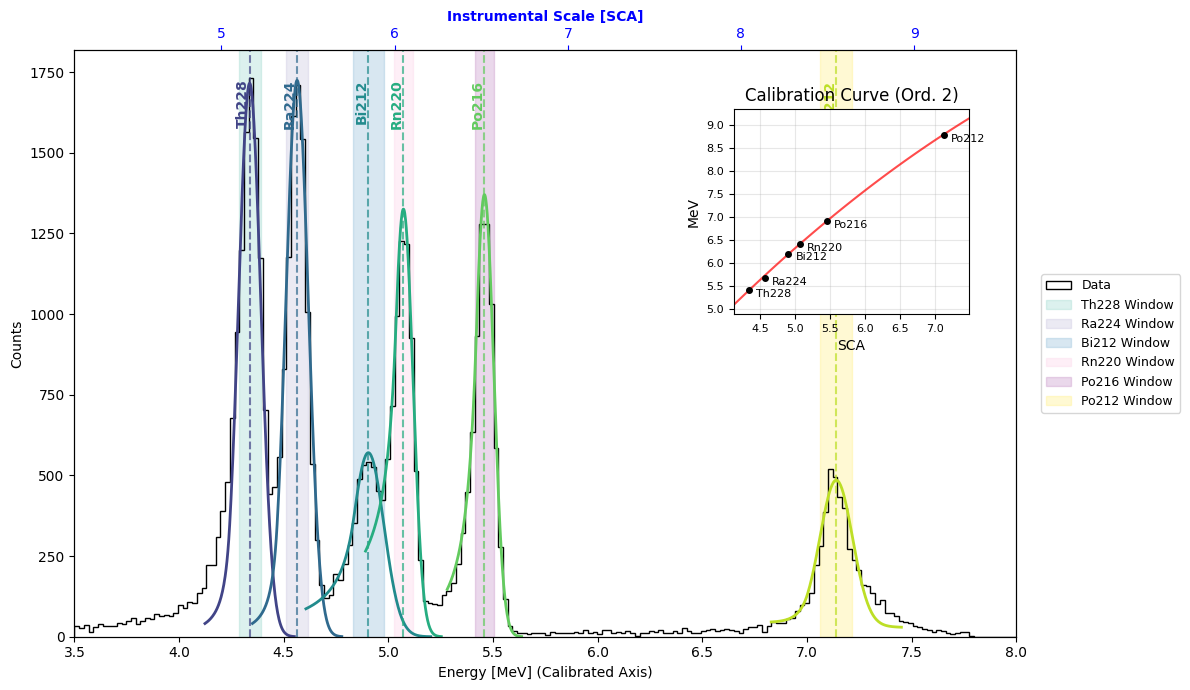

In [26]:
fig_summary = plot_calibration_summary(
        energies_SCA=energies_SCA,
        fit_results=fit_results,
        calib_coeffs=(set_alpha.calib_a, set_alpha.calib_b, set_alpha.calib_c),
        ranges_V=set_alpha.isotope_ranges_V,
        peak_definitions=ALPHA_PEAK_DEFINITIONS
)